### Business Context & Objectives :-

The Company operates a global e-commerce platform selling products acrsss categories including sporting goods, fitness equipment, outdoor gear, footwear, and apparel acress multiple international regions.

**Core Business Problem**

Actual shipping times frequently deviate from scheduled delivary windows, creating eroded customer trust, reduced order profitibility, and an inability to make relaible commitments to buyers at points of purchase.

**Analytical Objectives**



*   Understand the current state of delivary performance across all dimensions (region, mode, time, segment) .
*   Quantify the financial impact of delays on  order profitability.
*   Identify the primary operational bottlrnecks driving late delivaries.
*   Build a predective model to flag model high-risk orders before they are shipped.
*  Deliver actionable recommendations to improve on-time delivery and profitability.



### Business Problem

A global e-commerce company operating across multiple regions manages end-to-end order fulfillment,including shipping and delivery, for the products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late delivaries and unpredictable order profitabilty.

### Desired Outcome :

The goal is to analyse delivery operations, identify bottlenecks and build a predictive system to reduce delays, optimize shipping decisions and improve overall profitability and efficiency.

### Importing Basic Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as ticker
import matplotlib.cm as cm

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [ ]:
### The Dataset is taken from Kaggle

# https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Supply chain analysis Project using python/DataCoSupplyChainDataset.csv',encoding='latin-1')

pd.set_option('display.max_columns',None) # display all columns
pd.set_option('display.max_rows',100)

In [4]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.750000,0.29,1,327.750000,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.750000,-0.80,1,327.750000,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.750000,-0.80,1,327.750000,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.750000,0.08,1,327.750000,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.750000,0.45,1,327.750000,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,XXXXXXXXX,Home Office,NY,1322 Broad Glade,11207.0,7,Fan Shop,40.640930,-73.942711,Pacific Asia,Shanghái,China,1005,1/16/2016 3:40,26043,1004,0.000000,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,S

### Basic Checks Understanding of the Data .

In [4]:

# check the number of rows and columns
print(df.shape)
print("no.of Rows:", df.shape[0]) # 0 --> rows
print("no. of Columns:", df.shape[1]) # 1 --> columns

(180519, 53)
no.of Rows: 180519
no. of Columns: 53


In [ ]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

### Exploratory Data Analysis (EDA)

In [ ]:
# check first 5 rows
df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
# check last 5 rows
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,XXXXXXXXX,Home Office,NY,1322 Broad Glade,11207.0,7,Fan Shop,40.640930,-73.942711,Pacific Asia,Shanghái,China,1005,1/16/2016 3:40,26043,1004,0.0,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,9141,Clark,XXXXXXXXX,Corporate,CA,7330 Broad Apple Moor,93304.0,7,Fan Shop,35.362545,-119.018700,Pacific Asia,Hirakata,Japón,9141,1/16/2016 1:34,26037,1004,4.0,0.01,65161,399.980011,-1.55,1,399.980011,395.980011,-613.770019,Eastern Asia,Osaka,COMPLETE,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,291,Smith,XXXXXXXXX,Corporate,CT,97 Burning Landing,6010.0,7,Fan Shop,41.629959,-72.967155,Pacific Asia,Adelaide,Australia,291,1/15/2016 21:00,26024,1004,8.0,0.02,65129,399.980011,0.36,1,399.980011,391.980011,141.110001,Oceania,Australia del Sur,PENDING,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,2813,Smith,XXXXXXXXX,Consumer,PR,2585 Silent Autumn Landing,725.0,7,Fan Shop,18.213350,-66.370575,Pacific Asia,Adelaide,Australia,2813,1/15/2016 20:18,26022,1004,12.0,0.03,65126,399.980011,0.48,1,399.980011,387.980011,186.229996,Oceania,Australia del Sur,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Andrea,7547,Ortega,XXXXXXXXX,Consumer,PR,697 Little Meadow,725.0,7,Fan Shop,18.290380,-66.370613,Pacific Asia,Nagercoil,India,7547,1/15/2016 18:54,26018,1004,16.0,0.04,65113,399.980011,0.44,1,399.980011,383.980011,168.949997,South Asia,Tamil Nadu,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class


In [ ]:
# check the datatype of each columns

df.dtypes

,0
Type,object
Days for shipping (real),int64
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Delivery Status,object
Late_delivery_risk,int64
Category Id,int64
Category Name,object
Customer City,object


In [ ]:
# check the dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [ ]:
# check for unique values
df.nunique()

,0
Type,4
Days for shipping (real),7
Days for shipment (scheduled),4
Benefit per order,21998
Sales per customer,2927
Delivery Status,4
Late_delivery_risk,2
Category Id,51
Category Name,50
Customer City,563


In [5]:
# check for any missing values
df.isnull().sum().sort_values(ascending=False)

,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3
Days for shipment (scheduled),0
Sales per customer,0
Benefit per order,0
Delivery Status,0
Late_delivery_risk,0
Customer City,0


In [6]:
# check for duplicates in the dataset
df.duplicated().sum()

np.int64(0)

### Data Cleaning and Preprocessing

In [7]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [8]:
# Data Cleaning

columns_to_drop = ['Product Description',
 'Product Image','Customer Email','Customer Password','Customer Fname','Customer Lname','Customer Street',
 'Customer Zipcode','Latitude',
 'Longitude','Order Zipcode','Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price','Order Item Quantity',
 'Order Item Total', 'Category Id','Department Id','Order Id','Order Customer Id', 'Customer Id',
  'Product Card Id',
 'Product Category Id','Benefit per order', # identical to order profit per order
                   'Product Status', # have only one value
  'Customer City','Order City',  'Order Country','Order State','Customer State',  'Market',              ]

In [9]:
df[['Benefit per order','Order Profit Per Order']]

,Benefit per order,Order Profit Per Order
0,91.250000,91.250000
1,-249.089996,-249.089996
2,-247.779999,-247.779999
3,22.860001,22.860001
4,134.210007,134.210007
...,...,...
180514,40.000000,40.000000
180515,-613.770019,-613.770019
180516,141.110001,141.110001
180517,186.229996,186.229996


In [10]:
(df['Benefit per order'] == df['Order Profit Per Order']).value_counts()

,count
True,180519


In [11]:
df['Product Status']

,Product Status
0,0
1,0
2,0
3,0
4,0
...,...
180514,0
180515,0
180516,0
180517,0


In [12]:
df['Product Status'].value_counts()

,count
Product Status,
0,180519


In [13]:
#dropping columns that are either fully missing, redundant or have only one values ( and thus no variance)

df=df.drop(columns=columns_to_drop)

In [ ]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

In [14]:
# removing canceled orders since they are not relevent for delivary time and may lead to different patterns than completed orders

df=df[df['Delivery Status'] != 'Shipping canceled']

In [13]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,1/31/2018 22:56,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,1/13/2018 12:27,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,1/13/2018 12:06,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,1/13/2018 11:45,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,1/13/2018 11:24,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,1/15/2018 11:24,Standard Class


In [15]:
# Standard Date Conversion

for c in ['order date (DateOrders)', 'shipping date (DateOrders)'] :

  df[c] = pd.to_datetime(df[c],errors='coerce', dayfirst=False)

df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [ ]:
#after  data cleaning ,lets check the overview again to see how the dataset has changed !!!!

In [16]:
print('rows , columns :', df.shape)

rows , columns : (172765, 20)


In [16]:
print('Missing values :')
print(df.isna().sum().sort_values(ascending = False))

Missing values :
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer Country                 0
Customer Segment                 0
Department Name                  0
order date (DateOrders)          0
Order Item Profit Ratio          0
Sales                            0
Order Profit Per Order           0
Order Region                     0
Order Status                     0
Product Name                     0
Product Price                    0
shipping date (DateOrders)       0
Shipping Mode                    0
dtype: int64


In [17]:
# values counts for categorical columns with low cardinality

for col in df.columns:
  if df[col].nunique() < 10:
    print(f'{col} value counts :')
    print(df[col].value_counts())
    print('--------------------------------')

Type value counts :
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64
--------------------------------
Days for shipping (real) value counts :
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64
--------------------------------
Days for shipment (scheduled) value counts :
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64
--------------------------------
Delivery Status value counts :
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64
--------------------------------
Late_delivery_risk value counts :
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64
--------------------------------
Customer Country value counts :
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64
------------------------

In [17]:
# Calculating order processing time and delay

df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days  # when shipped and when order was booked || .dt.days -- to get the no. of days!!

In [18]:
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

In [19]:
df['Is_Delayed'] = df['Delay'] > 0 # delay days

In [20]:
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name() # week name
df['order_hours'] = df['order date (DateOrders)'].dt.hour

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172765 entries, 0 to 180518
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           172765 non-null  object        
 1   Days for shipping (real)       172765 non-null  int64         
 2   Days for shipment (scheduled)  172765 non-null  int64         
 3   Sales per customer             172765 non-null  float64       
 4   Delivery Status                172765 non-null  object        
 5   Late_delivery_risk             172765 non-null  int64         
 6   Category Name                  172765 non-null  object        
 7   Customer Country               172765 non-null  object        
 8   Customer Segment               172765 non-null  object        
 9   Department Name                172765 non-null  object        
 10  order date (DateOrders)        172765 non-null  datetime64[ns]
 11  Order

In [22]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hours
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [23]:
df['Is_Delayed'].value_counts()

,count
Is_Delayed,
True,94523
False,78242


In [24]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hours'],
      dtype='object')

In [34]:
#Working on business problem
#1. see wahts the profit / loss
#2.delivery time bases how it is affecting profit and loss


In [25]:
df['Order Profit Per Order'] # - ones are in loss and +ones are in profits

,Order Profit Per Order
0,91.250000
1,-249.089996
2,-247.779999
3,22.860001
4,134.210007
...,...
180514,40.000000
180515,-613.770019
180516,141.110001
180517,186.229996


In [26]:
df['Order Profit Per Order']>0

,Order Profit Per Order
0,True
1,False
2,False
3,True
4,True
...,...
180514,True
180515,False
180516,True
180517,True


In [ ]:
# lets break in to categories #profit #loss #breakeven

In [27]:
#Profitability Flag Based on Order Profit Per Order

df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0 ,'Profit',np.where(df['Order Profit Per Order'] < 0 ,'Loss','BreakEven'))

df['Profitability Flag'].head()

,Profitability Flag
0,Profit
1,Loss
2,Loss
3,Profit
4,Profit


In [28]:
print(df['Profitability Flag'].value_counts())

Profitability Flag
Profit       139354
Loss          32295
BreakEven      1116
Name: count, dtype: int64


In [29]:
df['Profitability Flag'].value_counts(normalize=True)

,proportion
Profitability Flag,
Profit,0.80661
Loss,0.18693
BreakEven,0.00646


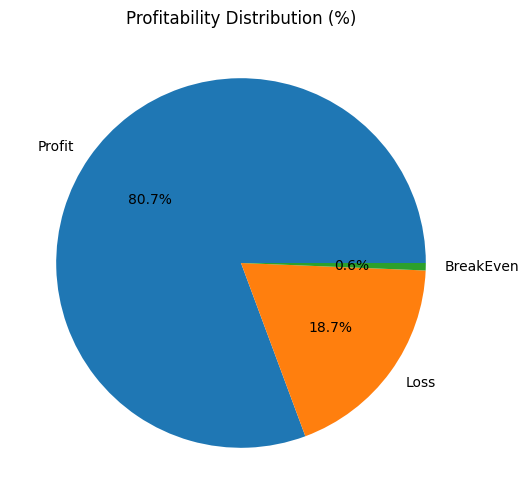

In [30]:
# To Visualise the Profitability Distribution

profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(profit_counts,
        labels=profit_counts.index,
        autopct='%1.1f%%')

plt.title('Profitability Distribution (%)')
plt.show()

In [ ]:
# lets make some business KPI's

In [49]:
df.columns.to_list()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Name',
 'Customer Country',
 'Customer Segment',
 'Department Name',
 'order date (DateOrders)',
 'Order Item Profit Ratio',
 'Sales',
 'Order Profit Per Order',
 'Order Region',
 'Order Status',
 'Product Name',
 'Product Price',
 'shipping date (DateOrders)',
 'Shipping Mode',
 'Order Processing Time',
 'Delay',
 'Is_Delayed',
 'order_month',
 'order_day',
 'order_hours',
 'Profitability Flag']

In [31]:
total_orders = df.shape[0]
print(total_orders)

172765


In [32]:
total_sales = df['Sales'].sum()

avg_order_value = df['Sales'].mean()

print(total_sales)
print('-------------------')
print(avg_order_value)

35214429.653478295
-------------------
203.82849334922173


In [33]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


# Filter delayed orders
delayed_df = df[df['Delay'] > 0]

metrics = {}

metrics['Total Orders'] = len(df)

metrics['Late Deliveries'] = len(delayed_df)

metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)

metrics['On-time Delivery %'] = (1 - metrics['Late Deliveries'] / metrics['Total Orders']) * 100

metrics['Late Delivery %'] = (metrics['Late Deliveries'] / metrics['Total Orders']) * 100

metrics['Total Profit'] = format_func(
    df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
)

metrics['Total Loss due to delays'] = format_func(
    df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum()
)


print("\n---  Business KPIs:  ---\n")

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


---  Business KPIs:  ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On-time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


In [ ]:
# Profitability vs Delivery Time Analysis

In [34]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order'].agg(
        mean_profit ='mean' ,
        total_profit = 'sum' ,
        order_count = 'count'
        ).reset_index()
)

In [35]:
print(profit_metrics)

   Delay  mean_profit  total_profit  order_count
0     -2    23.360134  4.875961e+05        20873
1     -1    21.604769  4.476292e+05        20719
2      0    22.249118  8.154302e+05        36650
3      1    22.333227  1.194895e+06        53503
4      2    21.128491  5.821110e+05        27551
5      3    20.031412  1.356527e+05         6772
6      4    21.368783  1.431067e+05         6697


In [36]:
profit_metrics = profit_metrics.round(3)
print(profit_metrics)

   Delay  mean_profit  total_profit  order_count
0     -2       23.360    487596.070        20873
1     -1       21.605    447629.211        20719
2      0       22.249    815430.191        36650
3      1       22.333   1194894.652        53503
4      2       21.128    582111.050        27551
5      3       20.031    135652.720         6772
6      4       21.369    143106.740         6697


In [73]:
## Delay Distribution

In [37]:
delay_distribution =(
    df['Delay'].value_counts(normalize = True).sort_index() * 100
).reset_index()

In [75]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


In [78]:
# Visualisation





Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


Text(0.5, 1.0, 'Profit Analysis by Delay Days')

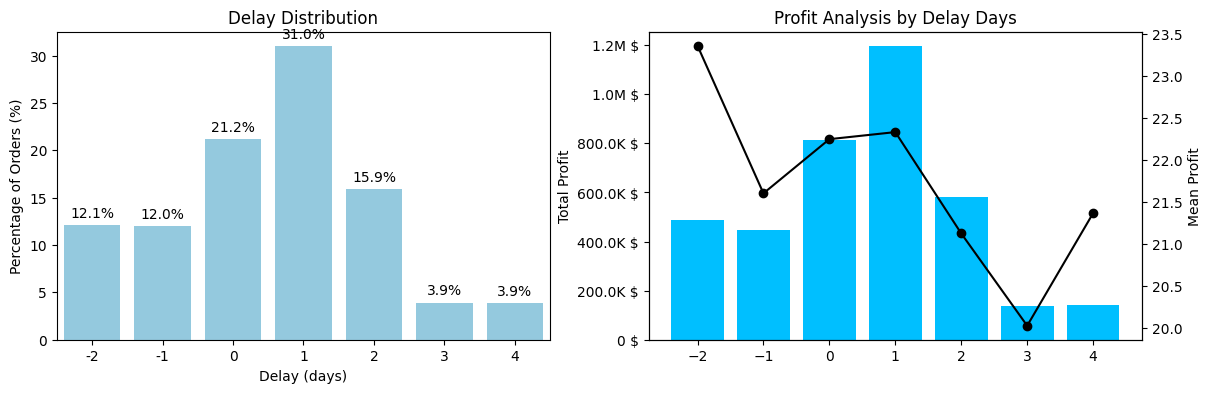

In [55]:

# Rename columns
delay_distribution.columns = ['Delay_Days', 'Percentage']

# Print outputs properly
print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Define a color (optional)
accent_color = 'skyblue'

# -------------------------------
# First subplot: Delay Distribution
# -------------------------------
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of Orders (%)')

# Add percentage labels on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

# -------------------------------
# Second subplot : Profit Analysis by Delay Days
# -------------------------------
# sns.lineplot(
#     data=profit_metrics,
#     x='Delay',
#     y='mean_profit',
#     ax=ax2
# )

# ax2.set_title('Profit vs Delay')
# ax2.set_xlabel('Delay (days)')
# ax2.set_ylabel('Mean Profit')

# plt.tight_layout()
# plt.show()

  # brighter than steelblue
ax2.set_ylabel("Total Profit", color='black')

ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label='Total Profit'
)

ax2.tick_params(axis='y', labelcolor='black')

# Twin axis for mean profit
ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color='black')

ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    color='black',
    label='Mean Profit'
)

ax3.tick_params(axis='y', labelcolor='black')

# -------- Format Total Profit Axis --------
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

# Title
ax3.set_title("Profit Analysis by Delay Days")

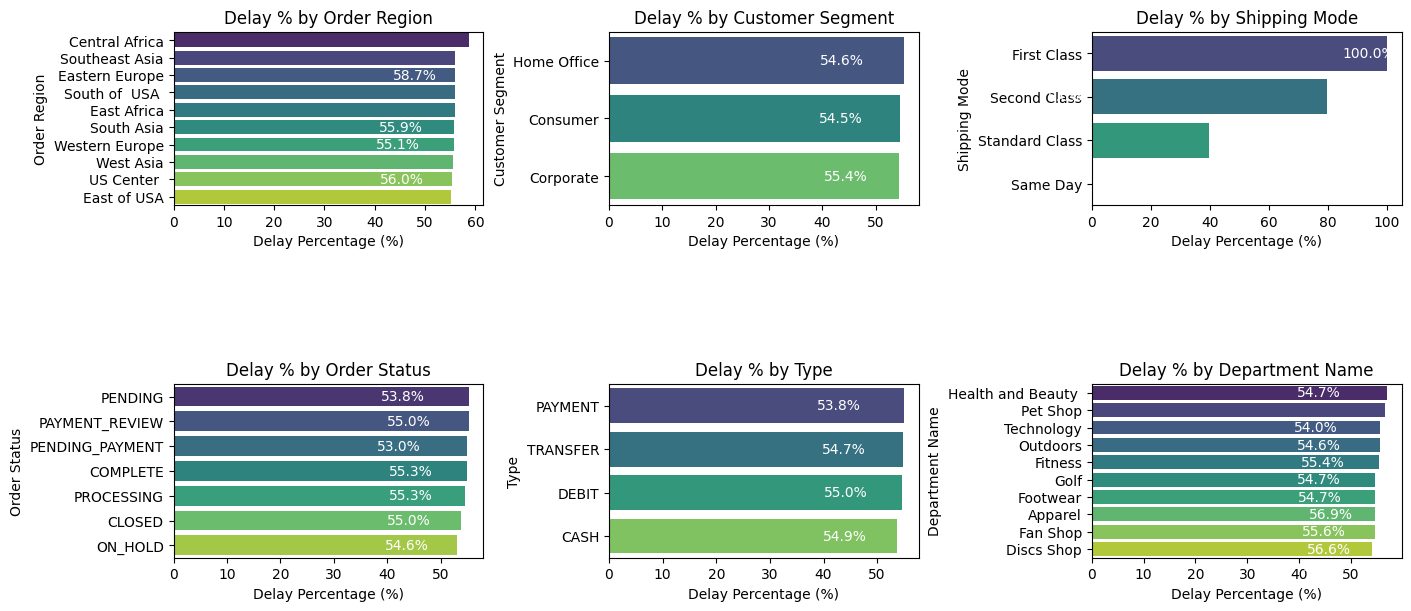

In [58]:
### Bottleneck Detactions : Identfying problems


# Function to compute delay %
def compute_delay_pct_by_category(category):
    cat_df = (
        df.groupby(category)
        .agg(
            total_orders=('Delay', 'count'),
            late_orders=('Is_Delayed', 'sum')
        ).reset_index()
    )

    cat_df['delay_pct'] = (cat_df['late_orders'] / cat_df['total_orders']) * 100

    # Sort and take top 10 bottlenecks
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)

    return cat_df


# Categories to analyze
categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 6), constrained_layout=True)
axes = axes.flatten()

# Loop through categories
for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('Delay Percentage (%)')
    ax.set_ylabel(category)

    # Add labels on bars
    for i, row in cat_df.iterrows():
        ax.text(
            row['delay_pct'] - 15,   # shift slightly left
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

plt.show()

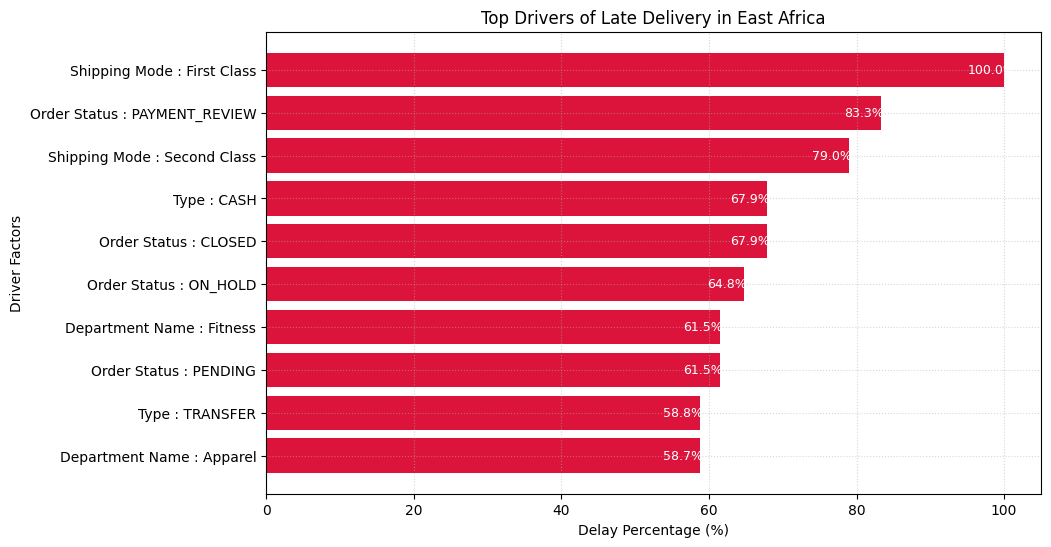

,Driver,Factor_Level,delay_pct,avg_delay,total_orders
0,Shipping Mode,Shipping Mode : First Class,100.000000,1.000000,277
20,Order Status,Order Status : PAYMENT_REVIEW,83.333333,1.000000,18
2,Shipping Mode,Shipping Mode : Second Class,79.036827,1.934844,353
13,Type,Type : CASH,67.924528,0.880503,159
17,Order Status,Order Status : CLOSED,67.924528,0.880503,159
19,Order Status,Order Status : ON_HOLD,64.761905,0.742857,105
9,Department Name,Department Name : Fitness,61.538462,0.923077,13
21,Order Status,Order Status : PENDING,61.502347,0.676056,213
16,Type,Type : TRANSFER,58.752998,0.621103,417
7,Department Name,Department Name : Apparel,58.730159,0.611111,504


In [60]:
#Root Cause Analysis : WHy Is the Delay Happening!

import matplotlib.pyplot as plt
import pandas as pd

# Root cause analysis function
def top_drivers_for_region(region):

    # Filter region data
    df_region = df[df['Order Region'] == region].copy()

    # Drivers to analyze
    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        # Calculate delay %
        temp['delay_pct'] = (temp['late_orders'] / temp['total_orders']) * 100

        # Add metadata
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        # Keep only needed columns
        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )

    # Combine all factors
    final_df = pd.concat(all_factors, ignore_index=True)

    # Top 10 drivers by delay %
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    # Plot
    plt.figure(figsize=(10, 6))

    bars = plt.barh(
        top_factors['Factor_Level'],
        top_factors['delay_pct'],
        color='crimson'
    )

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")

    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    # Add labels on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 5,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=9,
            color='white'
        )

    plt.show()

    return top_factors


# Example usage
top_drivers_for_region('East Africa')

In [61]:
### Time Based Analysis ------------------

In [62]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hours,Profitability Flag
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.750000,91.250000,Southeast Asia,COMPLETE,Smart watch,327.750000,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22,Profit
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.750000,-249.089996,South Asia,PENDING,Smart watch,327.750000,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12,Loss
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.750000,-247.779999,South Asia,CLOSED,Smart watch,327.750000,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12,Loss
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.750000,22.860001,Oceania,COMPLETE,Smart watch,327.750000,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11,Profit
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.750000,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.750000,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11,Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,399.980011,Shipping on time,0,Fishing,EE. UU.,Home Office,Fan Shop,2016-01-16 03:40:00,0.10,399.980011,40.000000,Eastern Asia,CLOSED,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-20 03:40:00,Standard Class,4,0,False,1,Saturday,3,Profit
180515,DEBIT,3,2,395.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,2016-01-16 01:34:00,-1.55,399.980011,-613.770019,Eastern Asia,COMPLETE,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-19 01:34:00,Second Class,3,1,True,1,Saturday,1,Loss
180516,TRANSFER,5,4,391.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,2016-01-15 21:00:00,0.36,399.980011,141.110001,Oceania,PENDING,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-20 21:00:00,Standard Class,5,1,True,1,Friday,21,Profit
180517,PAYMENT,3,4,387.980011,Advance shipping,0,Fishing,Puerto Rico,Consumer,Fan Shop,2016-01-15 20:18:00,0.48,399.980011,186.229996,Oceania,PENDING_PAYMENT,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,2016-01-18 20:18:00,Standard Class,3,-1,False,1,Friday,20,Profit


In [63]:
df['shipping date (DateOrders)'].min()

Timestamp('2015-01-03 00:00:00')

In [64]:
df['shipping date (DateOrders)'].max()

Timestamp('2018-02-06 22:14:00')

In [67]:
## Delay % By Month, Day Of Week , Hour

# Delay % by Month
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

# -------------------------------

# Delay % by Day of Week
delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

# -------------------------------

# Delay % by Hour
delay_by_hour = (
    df.groupby('order_hours')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100



In [70]:
print(delay_by_month)
print('-------------------------------')
print(delay_by_day)
print('-------------------------------')
print(delay_by_hour)
print('-------------------------------')

    order_month  Is_Delayed  delay_pct
0             1    0.542542  54.254150
1             2    0.546046  54.604550
2             3    0.548094  54.809390
3             4    0.545042  54.504230
4             5    0.549980  54.998022
5             6    0.547645  54.764535
6             7    0.537310  53.731048
7             8    0.553871  55.387128
8             9    0.553885  55.388454
9            10    0.540970  54.097044
10           11    0.548609  54.860878
11           12    0.552240  55.224003
-------------------------------
   order_day  Is_Delayed  delay_pct
0     Friday    0.544884  54.488442
1     Monday    0.555338  55.533838
2   Saturday    0.542619  54.261937
3     Sunday    0.551524  55.152418
4   Thursday    0.547202  54.720188
5    Tuesday    0.539841  53.984137
6  Wednesday    0.548452  54.845175
-------------------------------
    order_hours  Is_Delayed  delay_pct
0             0    0.540686  54.068641
1             1    0.554227  55.422680
2             2    0.551

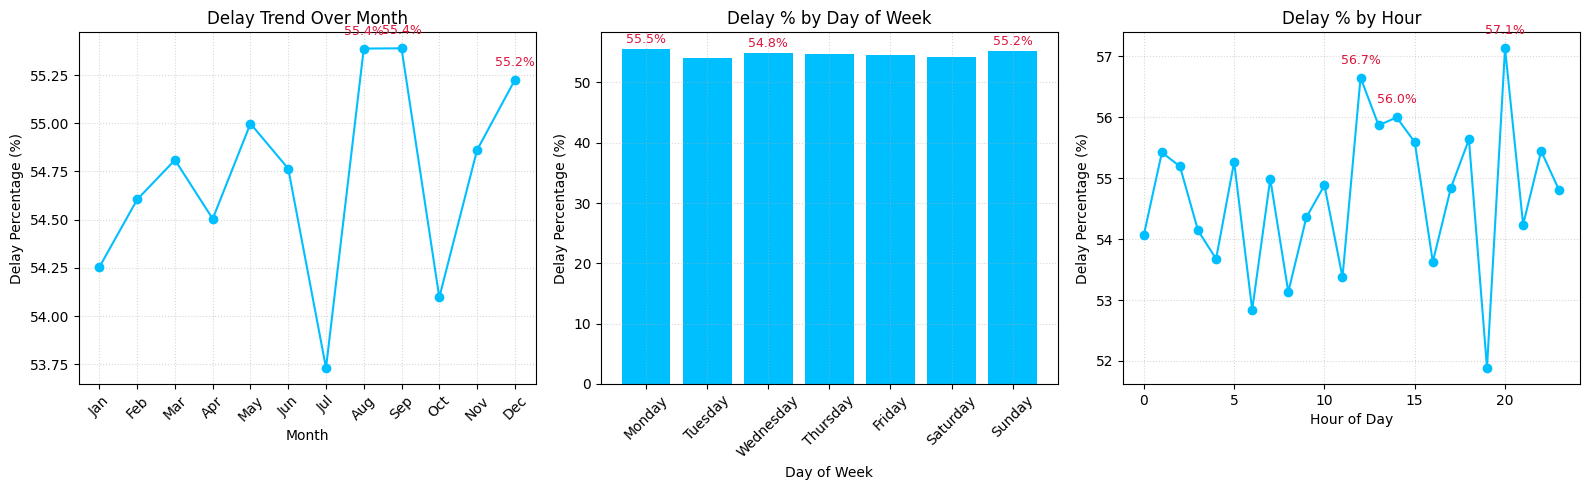

In [71]:
# Colors (define if not already)
primary_color = '#00BFFF'
danger_color = 'crimson'

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# -------------------------------
# Subplot 1: Delay % Trend Over Month
# -------------------------------
ax1.plot(
    delay_by_month['order_month'],
    delay_by_month['delay_pct'],
    marker='o',
    color=primary_color
)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=45
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest months
top3_month = delay_by_month.nlargest(3, 'delay_pct')

for _, row in top3_month.iterrows():
    ax1.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_month'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        color=danger_color
    )

# -------------------------------
# Subplot 2: Delay % by Day of Week
# -------------------------------
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(
    delay_by_day['order_day'],
    delay_by_day['delay_pct'],
    color=primary_color
)

ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 days
top3_day = delay_by_day.nlargest(3, 'delay_pct')

for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(
        row['order_day'],
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9,
        color=danger_color
    )

# -------------------------------
# Subplot 3: Delay % by Hour
# -------------------------------
ax3.plot(
    delay_by_hour['order_hours'],   # correct column name
    delay_by_hour['delay_pct'],
    marker='o',
    color=primary_color
)

ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 hours
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')

for _, row in top3_hour.iterrows():
    ax3.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_hours'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        color=danger_color
    )

plt.tight_layout()
plt.show()